<h1><b>Modul Pembelajaran Uninformed Search RKA 25</b></h1>

In [34]:
from data.utils import dfs, bfs, uniform_cost_search, visualize_maze
import numpy as np
from collections import deque
import inspect, heapq

In [35]:
def psource(*functions):
    "Print the source code for the given function(s)."
    code = '\n\n'.join(inspect.getsource(fn) for fn in functions)
    print(code)

<h2><b>1. Depth First Search</b></h2>
Depth-First Search (DFS) menelusuri simpul-simpul dengan cara masuk sedalam mungkin ke dalam satu jalur sebelum beralih mencoba jalur yang lain. Pendekatan ini membuat implementasi DFS umumnya lebih sederhana dan lebih hemat memori dibandingkan dengan Breadth-First Search (BFS).

Dalam prosesnya, DFS terus maju mengunjungi simpul baru di sepanjang jalur yang sedang dieksplorasi. Jika algoritma mencapai jalan buntu atau tidak ada lagi simpul baru yang bisa dijangkau dari titik tersebut, ia akan mundur ke persimpangan sebelumnya untuk menjelajahi cabang lain. Proses ini berlanjut hingga seluruh simpul dalam graf telah dikunjungi.

![](data\dfs_.gif)

Sumber GIF : https://takeuforward.org/data-structure/depth-first-search-dfs/

Penjelasan Depth-First Search (DFS):  
- Pencarian mendalam menyusuri satu cabang secara terus-menerus hingga ujung (leaf node) sebelum mundur (backtrack). 
- Menggunakan struktur data LIFO (Stack).

Mekanisme setiap langkah DFS:
- Mulai dari root node
- Eksplorasi cabang paling kiri hingga leaf node (atau dead end)
- Jika bukan goal → backtrack ke node sebelumnya yang memiliki cabang belum dieksplorasi
- Ulangi hingga goal ditemukan atau semua node terkunjungi

Kelebihan DFS:
- Efisien dalam memori = $O(bm)$ (hanya menyimpan jalur dari root ke node saat ini)
- Cepat menemukan solusi jika goal berada jauh di kedalaman suatu cabang pencarian

Kekurangan DFS:
- Tidak complete = Bisa terjebak dalam infinite loop (pada graf bersiklus atau kedalaman tak hingga)
- Tidak optimal = Solusi pertama yang ditemukan belum tentu jalur terpendek


<b>Implementasi DFS</b>

Struktur Graf
- A terhubung ke B, C
- B terhubung ke D, E
- C terhubung ke F
- D, E, F tidak memiliki cabang

In [36]:
psource(dfs)

def dfs(adj: dict, start, visited=None, path=None):
    if visited is None:
        visited = set()
        path = []
        
    visited.add(start)
    path.append(start)
    
    for neighbor in adj.get(start, []):
        if neighbor not in visited:
            dfs(adj, neighbor, visited, path)
            
    return path



In [37]:
adj = {
    'A': ['B', 'C'],
    'B': ['D', 'E'],
    'C': ['F'],
    'D': [],
    'E': [],
    'F': []
}

dfs(adj, start='A')

['A', 'B', 'D', 'E', 'C', 'F']

<b>PR DFS Algorithm</b>

Musael mempunyai sebuah labirin dungeon dengan ukuran 5x5. Ia ingin menguji coba menyelesaikan labirin itu dengan algoritma DFS. Bantulah Musael untuk menyelesaikannya!

In [38]:
def dfs_grid(maze, start, goal):
    stack = [(start, [])]
    visited = set()
    
    while stack:
        current, path = stack.pop()
        x, y = current
        
        if current == goal:
            return path + [current]
        
        if current in visited:
            continue
        
        visited.add(current)
        
        for dx, dy in [(0, 1), (1, 0), (0, -1), (-1, 0)]:
            nx, ny = x + dx, y + dy
            if 0 <= nx < len(maze) and 0 <= ny < len(maze[0]) and maze[nx][ny] != 1:
                stack.append(((nx, ny), path + [current]))

    return None

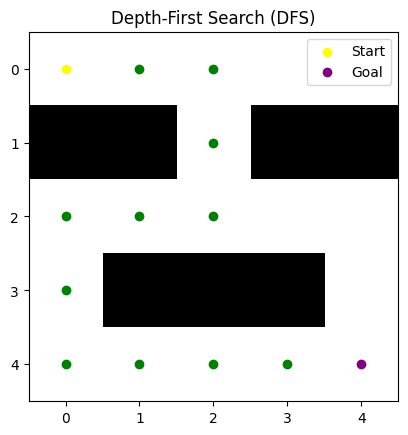

In [39]:
maze = np.array([
    [0, 0, 0, 0, 0],
    [1, 1, 0, 1, 1],
    [0, 0, 0, 0, 0],
    [0, 1, 1, 1, 0],
    [0, 0, 0, 0, 0]
])

start = (0, 0)
goal = (4, 4)

path_dfs = dfs_grid(maze, start, goal)
visualize_maze(maze, start, goal, path_dfs, algo='dfs')

<h2><b>2. Breath First Search</b></h2>
Breadth-First Search (BFS) menelusuri simpul-simpul dalam urutan berdasarkan jaraknya yang semakin meningkat dari simpul awal. Dengan demikian, BFS dapat digunakan untuk menghitung jarak dari simpul awal ke semua simpul lainnya. Namun, implementasi BFS umumnya lebih kompleks dibandingkan dengan Depth-First Search (DFS).

Dalam prosesnya, BFS menjelajahi simpul-simpul secara berlapis. Algoritma ini pertama-tama mengunjungi semua simpul yang kedalamannya 1 dari simpul awal, lalu kedalamannya 2, dst. Proses ini berlanjut hingga seluruh simpul dalam graf telah dikunjungi.

![](data\bfs_.gif)

Sumber GIF : https://takeuforward.org/graph/breadth-first-search-bfs-level-order-traversal

Penjelasan Breadth-First Search (BFS):  
- Pencarian melebar yang mengeksplorasi node level demi level secara horizontal. 
- Menggunakan struktur data FIFO (Queue).

Mekanisme setiap langkah BFS:
- Set level = 0
- Eksplorasi semua node pada level saat ini dari kiri ke kanan
- Jika goal ditemukan → selesai
- Jika tidak → turun ke level berikutnya (level + 1)
- Ulangi proses

Kelebihan BFS:
- Complete = Pasti menemukan solusi jika jalan keluar tersedia
- Optimal = Menemukan solusi dengan depth minimum (asumsi cost setiap langkah seragam)

Kekurangan BFS:
- Boros memori = $O(b^d)$ (harus menyimpan semua node pada level saat ini sebelum ke level berikutnya)
- Overhead komputasi = Sangat lambat jika percabangan (branching factor) besar

<b>Implementasi BFS</b>

In [40]:
psource(bfs)

def bfs(adj, start):
    visited = set()
    res = []
    
    q = deque()
    visited.add(start)
    q.append(start)

    while q:
        curr = q.popleft()
        res.append(curr)

        for neighbor in adj[curr]:
            if neighbor not in visited:
                visited.add(neighbor)
                q.append(neighbor)
                
    return res



In [41]:
adj = {
    'A': ['B', 'C'],
    'B': ['D', 'E'],
    'C': ['F'],
    'D': [],
    'E': [],
    'F': []
}

bfs(adj, start='A')

['A', 'B', 'C', 'D', 'E', 'F']

<b>PR BFS Algorithm</b>

Lifanom menemukan labirin milik Musael dan mendapat informasi bahwa terdapat harta karun bernama One Piece di labirin tersebut. One Piece berada di (4, 0). Bantulah lifanom untuk sampai ke harta tersebut dengan algoritma BFS!

In [42]:
def bfs_grid(maze, start, goal):
    rows, cols = maze.shape
    visited = set()
    q = deque([(start, [start])])
    visited.add(start)

    directions = [(-1, 0), (1, 0), (0, -1), (0, 1)]

    while q:
        curr, path = q.popleft()

        if curr == goal:
            return path

        r, c = curr
        for dr, dc in directions:
            nr, nc = r + dr, c + dc
            
            if 0 <= nr < rows and 0 <= nc < cols:
                if str(maze[nr, nc]) != '1' and (nr, nc) not in visited:
                    visited.add((nr, nc))
                    q.append(((nr, nc), path + [(nr, nc)]))
                    
    return []

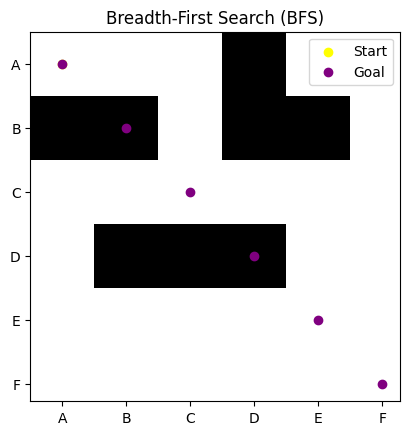

In [43]:
maze = np.array([
    [0, 0, 0, 1, 0],
    [1, 1, 0, 1, 1],
    [0, 0, 0, 0, 0],
    [0, 1, 1, 1, 0],
    [0, 0, 0, 0, 0]
])

start = (0, 0)
goal = (_, _) 

path_bfs = bfs_grid(maze, start, goal)
visualize_maze(maze, start, goal, path_bfs, algo='bfs')

<h2><b>3. Uniform Cost Search</b></h2>
Uniform Cost Search (UCS) menelusuri simpul-simpul berdasarkan total akumulasi biaya termurah dari simpul awal. Berbeda dengan BFS yang hanya menghitung jumlah langkah, UCS secara spesifik digunakan pada graf di mana setiap rute atau transisi memiliki bobot dan nilai yang berbeda-beda.

Dalam prosesnya, UCS selalu memilih untuk mengekspansi jalur yang memakan biaya paling kecil terlebih dahulu. Jika algoritma menemukan rute alternatif yang terbukti lebih murah menuju suatu simpul, rute tersebut akan diperbarui. Proses ini berlanjut secara bertahap hingga jalur paling hemat biaya menuju tujuan akhir berhasil ditemukan.

![](data\ucs_.gif)

Sumber GIF : https://github.com/aghdamamir/UCS-and-A-star-search

Penjelasan Uniform Cost Search (UCS):  
- Pencarian berdasarkan total cost terendah. 
- Mengembangkan BFS untuk graf dengan bobot edge yang bervariasi. 
- Menggunakan Priority Queue berdasar total cost akumulatif (g(n)).

Mekanisme setiap langkah UCS:
- Set node awal dengan cost = 0
- Keluarkan node dengan total cost (g(n)) paling kecil dari priority queue
- Jika goal ditemukan → selesai
- Jika tidak → ekspansi node, hitung akumulasi cost anak-anaknya, masukkan ke antrean
- Ulangi proses

Kelebihan UCS:
- Complete = Selama cost setiap langkah lebih dari nol
- Optimal = Pasti menemukan solusi dengan total cost terendah pada bobot yang bervariasi

Kekurangan UCS:
- Memori dan komputasi besar = Harus menyimpan dan mengurutkan banyak node dalam priority queue
- Tidak terarah = Lambat jika terdapat banyak jalur berbiaya kecil yang menjauhi goal


<b>Implementasi UCS</b>

In [44]:
psource(uniform_cost_search)

def uniform_cost_search(graph, start, goal):
    priority_queue = [(0, start)]
    visited = {start: (0, None)}
    
    while priority_queue:
        current_cost, current_node = heapq.heappop(priority_queue)
        
        if current_node == goal:
            return current_cost, reconstruct_path(visited, start, goal)
            
        for neighbor, cost in graph[current_node]:
            total_cost = current_cost + cost
            
            if neighbor not in visited or total_cost < visited[neighbor][0]:
                visited[neighbor] = (total_cost, current_node)
                heapq.heappush(priority_queue, (total_cost, neighbor))
                
    return None



In [45]:
adj_ucs = {
    'A': [('B', 1), ('C', 4)],
    'B': [('C', 2), ('D', 5)],
    'C': [('D', 1)],
    'D': []
}

print(uniform_cost_search(adj_ucs, 'A', 'D'))

(4, ['A', 'B', 'C', 'D'])


<b>PR UCS Algorithm</b>

Rafas mempunyai robot. Ia memberi task kepada robot tersebut untuk bergerak dari titik awal (0, 0) menuju titik tujuan (4, 4) pada sebuah area yang direpresentasikan dengan matriks grid 5x5. Setiap sel pada grid berisi nilai bilangan bulat yang menunjukkan biaya (cost) energi untuk melintasi sel tersebut. Nilai 0 merepresentasikan rintangan yang tidak dapat dilewati. Tentukan jalur dengan total biaya energi paling minimum yang harus dilalui robot menggunakan algoritma Uniform Cost Search (UCS).

In [46]:
import heapq

def ucs_grid(grid, start, goal):
    rows = len(grid)
    cols = len(grid[0])
    
    pq = [(0, start, [start])]
    visited_costs = {start: 0}
    
    directions = [(-1, 0), (1, 0), (0, -1), (0, 1)]

    while pq:
        cost, curr, path = heapq.heappop(pq)

        if curr == goal:
            return cost, path

        if cost > visited_costs.get(curr, float('inf')):
            continue

        r, c = curr
        for dr, dc in directions:
            nr, nc = r + dr, c + dc
            
            if 0 <= nr < rows and 0 <= nc < cols and grid[nr][nc] != 1:
                new_cost = cost + grid[nr][nc]
                
                if new_cost < visited_costs.get((nr, nc), float('inf')):
                    visited_costs[(nr, nc)] = new_cost
                    heapq.heappush(pq, (new_cost, (nr, nc), path + [(nr, nc)]))
                    
    return float('inf'), []

In [47]:
grid = [
    [1, 3, 1, 1, 1],
    [1, 0, 5, 0, 1],
    [2, 2, 1, 1, 8],
    [1, 0, 0, 4, 1],
    [1, 1, 1, 2, 1]
]

start = (0, 0)
goal = (4, 4)

min_cost, best_path = ucs_grid(grid, start, goal)

print(f"Biaya Minimum: {min_cost}")
print(f"Jalur: {best_path}")

Biaya Minimum: inf
Jalur: []


<h2><b>4. DLS (Depth-Limited Search)</b></h2>

DLS merupakan algoritma pencarian berbasis DFS yang membatasi kedalaman eksplorasi hingga batas tertentu (limit)

DLS = DFS + kondisi berhenti jika depth melebihi limit

Mekanisme setiap langkah:
- Mulai dari node awal dengan depth = 0
- Gunakan DFS hingga batas depth (limit)
- Jika node = goal → selesai
- Jika depth < limit → ekspansi neighbor
- Jika mencapai limit → hentikan (cutoff)
- Ulangi hingga goal ditemukan atau semua jalur habis

kelebihan DLS
- Efisien dalam penggunaan memori (O(d)), seperti DFS.
- Mencegah eksplorasi tak terbatas dengan membatasi kedalaman pencarian.
- Memberikan kontrol eksplorasi melalui parameter depth limit.
- Menjadi dasar utama dalam Iterative Deepening Search (IDS).

Kekurangan
- Tidak complete jika depth limit lebih kecil dari kedalaman goal.
- Tidak menjamin solusi optimal (tidak selalu jalur terpendek).
- Bergantung pada pemilihan depth limit yang biasanya tidak diketahui.
- Mengembalikan cutoff jika goal berada di luar limit, meskipun solusi sebenarnya ada.

![](data\dfs.gif)

![](data\dls.gif)


<b>Implementasi DLS</b>

Raka sedang menjelajahi jaringan gua bawah tanah.
Setiap gua terhubung dengan beberapa gua lain melalui lorong.

Struktur koneksi antar gua direpresentasikan sebagai graph berikut:
- A -> B, C
- B -> D, E
- C -> F, G
- D -> H, I
- H -> J -> K -> L

Raka ingin mencapai gua F, tetapi ia hanya bisa menjelajah
hingga kedalaman tertentu (depth limit).

Gunakan algoritma Depth-Limited Search (DLS) untuk menentukan
jalur yang Raka lalui untuk dapat mencapai gua tujuan.

In [48]:
# Representasi Graf
graph = {
    'A': ['B', 'C'],
    'B': ['D', 'E'],
    'C': ['F', 'G'],
    'D': ['H', 'I'],
    'E': [],
    'F': [],
    'G': [],
    'H': ['J'],
    'I': [],
    'J': ['K'],
    'K': ['L'],
    'L': []
}

In [49]:
def dls(graph, start, goal, limit):
    stack = [(start, [start], 0)]  # (node, path, depth)

    while stack:
        node, path, depth = stack.pop()

        if node == goal:
            return path

        if depth < limit:
            for neighbor in reversed(graph[node]):
                stack.append((neighbor, path + [neighbor], depth + 1))

    return None

In [50]:
dls(graph, 'A', 'F', limit=2)

['A', 'C', 'F']

<b> PR DLS Algorithm </b>

Rina berada di dalam dungeon dan ingin menemukan jalan keluar.
Setiap posisi direpresentasikan sebagai node dalam grid. Gunakan DLS untuk mencari jalur dari start ke goal.

In [51]:
maze = [
    [0,0,0,0,0],
    [1,1,0,1,1],
    [0,0,0,0,0],
    [0,1,1,1,0],
    [0,0,0,0,0]
]

start = (0,0)
goal = (4,4)
limit = 10

In [52]:
def dls_grid(maze, start, goal, limit):
    stack = [(start, 0, [start])]
    visited = set()

    while stack:
        (x, y), depth, path = stack.pop()   

        if (x, y) == goal:                  
            return path

        if (x, y) in visited:
            continue

        visited.add((x, y))                  

        if depth < limit:
            directions = [(0,1), (0,-1), (1,0), (-1,0)]

            for dx, dy in directions:
                nx, ny = x + dx, y + dy

                if 0 <= nx < len(maze) and 0 <= ny < len(maze[0]) and maze[nx][ny] != 1:
                    stack.append(((nx, ny), depth + 1, path + [(nx, ny)]))  

    return None

<h2><b>5. IDS (Iterative Deepening Search)</b></h2>

![](data\ids.gif)


Penjelasan Iterative Deepening Search (IDS):

- Menggabungkan Depth-First Search (DFS) dengan peningkatan batas kedalaman (depth limit) secara bertahap. Menjalankan Depth-Limited Search (DLS) berulang kali sampai solusi ditemuk
- IDS = serangkaian DLS dengan depth limit 0, 1, 2, …, hingga goal ditemukan
- IDS adalah DLS yang dijalankan berulang dengan depth limit yang meningkat

Mekanisme setiap langkah IDS (Iterative Deepening Search):
- Set limit awal = 0
- Jalankan DLS dengan limit tersebut
- Jika goal ditemukan → selesai
- Jika tidak → naikkan limit (limit + 1)
- Ulangi proses hingga goal ditemukan atau batas maksimum tercapai

Kelebihan IDS
- Hemat memori
- Complete =
Pasti menemukan solusi jika ada (dengan branching factor terbatas)
- Optimal (untuk cost seragam) = Menemukan solusi dengan depth minimum (seperti BFS)
- Tidak butuh informasi tambahan = Tidak perlu heuristic (berbeda dengan informed search)

Kekurangan IDS
- Re-computation (pengulangan) = Node yang sama dikunjungi berkali-kali
- Overhead waktu
- Tidak cocok untuk Depth solusi sangat besar


In [53]:
# Implementasi IDS
graph = {
    'A': ['B', 'C'],
    'B': ['D', 'E'],
    'C': ['F', 'G'],
    'D': ['H', 'I'],
    'E': [],
    'F': [],
    'G': [],
    'H': ['J'],
    'I': [],
    'J': ['K'],
    'K': ['L'],
    'L': []
}

In [54]:
def dls_with_path(graph, start, goal, limit):
    stack = [(start, [start], 0)]

    while stack:
        node, path, depth = stack.pop()

        if node == goal:
            return path

        if depth < limit:
            for neighbor in reversed(graph[node]):
                stack.append((neighbor, path + [neighbor], depth + 1))

    return None

def ids(graph, start, goal, max_depth):
    for limit in range(max_depth + 1):
        result = dls_with_path(graph, start, goal, limit)

        if result:
            print(f"Goal ditemukan di depth {limit}")
            return result

    print("Goal tidak ditemukan")
    return None

In [55]:
ids(graph, 'A', 'F', 5)

Goal ditemukan di depth 2


['A', 'C', 'F']

<b> PR IDS Algorithm</b>

Raka berada di dalam dungeon berbentuk grid.
Ia ingin mencapai pintu keluar, tetapi tidak tahu
berapa langkah yang dibutuhkan.

Ia mencoba mencari jalur secara bertahap:
mencoba kedalaman kecil dulu, lalu meningkatkannya.

Gunakan algoritma Iterative Deepening Search (IDS)
untuk menemukan jalur menuju goal.

In [56]:
maze = [
    [0,0,0,0,0],
    [1,1,0,1,1],
    [0,0,0,0,1],
    [0,1,1,1,0],
    [0,0,0,0,0]
]

start = (0,0)
goal = (4,4)

In [57]:
# lengkapi kode yang rumpang berikut dan uji apakah IDS berhasil menemukan path dari start ke goal pada maze di atas
def dls_grid_with_path(maze, start, goal, limit):
    stack = [(start, [start], 0)]
    visited = set()

    while stack:
        (x, y), path, depth = stack.pop()   

        if (x, y) == goal:                  
            return path

        if (x, y) in visited:
            continue
        
        visited.add((x, y))                  

        if depth < limit:
            for dx, dy in [(0, 1), (0, -1), (1, 0), (-1, 0)]:
                nx, ny = x + dx, y + dy
                if 0 <= nx < len(maze) and 0 <= ny < len(maze[0]) and maze[nx][ny] != 1:
                    stack.append(((nx, ny), path + [(nx, ny)], depth + 1))

    return None


def ids_grid(maze, start, goal, max_depth):
    for limit in range(max_depth):
        result = dls_grid_with_path(maze, start, goal, limit)
        if result:
            return result

    return None

<h2><b>6. Bidirectional Search</b></h2>

![](data\bidirectional.png)


Penjelasan Bidirectional Search (BDS):

- Menggunakan dua proses pencarian secara bersamaan: satu dari start node dan satu dari goal node
- Kedua pencarian berjalan (umumnya dengan BFS) hingga bertemu di suatu node (meeting point)
- Solusi diperoleh dengan menggabungkan jalur dari start ke meeting point dan dari goal ke meeting point
- BDS mengurangi kompleksitas pencarian dengan membagi kedalaman pencarian menjadi dua bagian

**Mekanisme setiap langkah Bidirectional BFS:**

- Inisialisasi dua queue:
  - dari start dan dari goal  
- Inisialisasi dua visited:
  - `visited_start` dan `visited_goal`  

- Selama kedua queue tidak kosong:

  - Ekspansi dari sisi start:
    - Ambil node dari queue  
    - Tambahkan neighbor yang belum dikunjungi  
    - Jika neighbor sudah ada di sisi goal → titik temu ditemukan  

  - Ekspansi dari sisi goal:
    - Ambil node dari queue  
    - Tambahkan neighbor yang belum dikunjungi  
    - Jika neighbor sudah ada di sisi start → titik temu ditemukan  

- Jika titik temu ditemukan:
  - Gabungkan jalur dari start dan goal menggunakan `build_path()`  

- Jika tidak ada pertemuan hingga queue habis:
  - Tidak ada solusi  

Kelebihan Bidirectional Search
- Lebih cepat =  karena mencari dari dua arah sekaligus
- Hemat memori = Frontier yang disimpan jauh lebih kecil dibanding BFS satu arah
- Complete & Optimal = Pasti menemukan solusi dengan jumlah langkah minimum pada graph tidak berbobot
- Tidak butuh heuristic = Berbeda dengan informed search, tidak perlu informasi tambahan

Kekurangan Bidirectional Search
- Butuh goal eksplisit = Tidak bisa digunakan jika goal tidak diketahui atau tidak terdefinisi dengan jelas
- Implementasi kompleks = Perlu mengelola dua frontier sekaligus dan mendeteksi titik temu antar keduanya
- Tidak selalu optimal pada graph berbobot = Perlu modifikasi tambahan seperti Bidirectional Dijkstra
- Overhead pengecekan = Setiap langkah harus mengecek perpotongan dua visited yang terus berkembang

![](data\bidirectional_implementasi.png)
Gunakan Bidirectional Search untuk menemukan jalur dari start (node 1) ke goal (node 14).


In [58]:
graph_bidirectional = {
    0: [4],
    1: [4],
    2: [5],
    3: [5],
    4: [0,1,6],
    5: [2,3,6],
    6: [4,5,7],
    7: [6,8],
    8: [7,9,10],
    9: [8,11,12],
    10: [8,13,14],
    11: [9],
    12: [9],
    13: [10],
    14: [10]
}

In [59]:
from collections import deque

def bidirectional_bfs(graph_bidirectional, start, goal):
    if start == goal:
        return [start]

    queue_start = deque([start])
    queue_goal = deque([goal])

    visited_start = {start: None}
    visited_goal = {goal: None}

    while queue_start and queue_goal:

        # expand dari start
        current = queue_start.popleft()
        for neighbor in graph_bidirectional[current]:
            if neighbor not in visited_start:
                visited_start[neighbor] = current
                queue_start.append(neighbor)

                if neighbor in visited_goal:
                    return build_path(neighbor, visited_start, visited_goal)

        # expand dari goal
        current = queue_goal.popleft()
        for neighbor in graph_bidirectional[current]:
            if neighbor not in visited_goal:
                visited_goal[neighbor] = current
                queue_goal.append(neighbor)

                if neighbor in visited_start:
                    return build_path(neighbor, visited_start, visited_goal)

    return None

In [60]:
def build_path(meeting, visited_start, visited_goal):
    path_start = []
    node = meeting

    while node is not None:
        path_start.append(node)
        node = visited_start[node]

    path_start.reverse()

    path_goal = []
    node = visited_goal.get(meeting)

    while node is not None:
        path_goal.append(node)
        node = visited_goal[node]

    return path_start + path_goal

In [61]:
bidirectional_bfs(graph_bidirectional, 1, 14)

[1, 4, 6, 7, 8, 10, 14]

<b>PR Bidirectional Search </b>

Seekor kuda berada di papan catur berukuran 8x8. Ia ingin mencapai posisi target. Untuk mempercepat pencarian, digunakan strategi dua arah:
- dari posisi awal
- dari posisi tujuan

Ketika kedua pencarian bertemu, jalur ditemukan.

Gunakan Bidirectional Search untuk menemukan jalur pergerakan kuda.

![](data\Knight2.gif)


In [62]:
start = (0, 0)
goal = (7, 7)

In [63]:
def get_knight_moves(pos):
    x, y = pos
    
    moves = [
        (x+2, y+1), (x+2, y-1),
        (x-2, y+1), (x-2, y-1),
        (x+1, y+2), (x+1, y-2),
        (x-1, y+2), (x-1, y-2)
    ]
    
    valid_moves = []
    for nx, ny in moves:
        if 0 <= nx < 8 and 0 <= ny < 8:
            valid_moves.append((nx, ny))
    
    return valid_moves

In [64]:
from collections import deque

def bidirectional_knight(start, goal):
    if start == goal:
        return [start]

    queue_start = deque([start])
    queue_goal = deque([goal])

    visited_start = {start: None}
    visited_goal = {goal: None}

    while queue_start and queue_goal:

        current = queue_start.popleft()
        for nxt in get_knight_moves(current):
            if nxt not in visited_start:
                visited_start[nxt] = current
                queue_start.append(nxt)
                if nxt in visited_goal:
                    return build_path(nxt, visited_start, visited_goal)

        current = queue_goal.popleft()
        for nxt in get_knight_moves(current):
            if nxt not in visited_goal:
                visited_goal[nxt] = current
                queue_goal.append(nxt)
                if nxt in visited_start:
                    return build_path(nxt, visited_start, visited_goal)

    return None

In [65]:
def build_path(meeting, visited_start, visited_goal):
    path_start = []
    node = meeting
    
    while node is not None:
        path_start.append(node)
        node = visited_start[node]
    
    path_start.reverse()
    
    path_goal = []
    node = visited_goal[meeting]
    
    while node is not None:
        path_goal.append(node)
        node = visited_goal[node]
        
    return path_start + path_goal

In [66]:
path = bidirectional_knight(start, goal)

print("Path:", path)
print("Jumlah langkah:", len(path)-1 if path else None)

Path: [(0, 0), (2, 1), (4, 2), (5, 4), (7, 5), (5, 6), (7, 7)]
Jumlah langkah: 6
